# Medical insurance Model

In [1]:
# imports
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

In [2]:
dataset = pd.read_csv("../datasets/medical_insurance.csv")

dataset.head()

,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
0,75722,52,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,...,0,1,0,1,0,2,0,1,0,0
1,80185,79,Female,North,Urban,12800.0,No HS,Married,Employed,3,...,0,1,1,0,0,1,0,1,1,0
2,19865,68,Male,North,Rural,40700.0,HS,Married,Retired,5,...,0,0,1,1,0,2,1,0,1,0
3,76700,15,Male,North,Suburban,15600.0,Some College,Married,Self-employed,5,...,0,0,0,1,0,0,1,0,0,0
4,92992,53,Male,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,...,0,1,0,2,0,1,1,0,1,0


In [3]:
dataset.describe().loc[["count", "mean", "min", "max"]]

,person_id,age,income,household_size,dependents,bmi,visits_last_year,hospitalizations_last_3yrs,days_hospitalized_last_3yrs,medication_count,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
count,100000.0,100000.0000,100000.000,100000.0000,100000.00000,100000.000000,100000.00000,100000.00000,100000.00000,100000.00000,...,100000.00000,100000.00000,100000.00000,100000.00000,100000.00000,100000.00000,100000.00000,100000.00000,100000.00000,100000.0000
mean,50000.5,47.5215,49873.905,2.4309,0.89838,26.990512,1.92765,0.09364,0.37335,1.23632,...,0.01477,0.10831,0.13014,0.50853,0.15869,0.50839,0.50933,0.50914,0.36781,0.1697
min,1.0,0.0000,1100.000,1.0000,0.00000,12.000000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.0000
max,100000.0,100.0000,1061800.000,9.0000,7.00000,50.400000,25.00000,3.00000,21.00000,11.00000,...,1.00000,1.00000,1.00000,7.00000,6.00000,7.00000,7.00000,7.00000,1.00000,1.0000


In [4]:
dataset.isna().sum()

person_id                          0
age                                0
sex                                0
region                             0
urban_rural                        0
income                             0
education                          0
marital_status                     0
employment_status                  0
household_size                     0
dependents                         0
bmi                                0
smoker                             0
alcohol_freq                   30083
visits_last_year                   0
hospitalizations_last_3yrs         0
days_hospitalized_last_3yrs        0
medication_count                   0
systolic_bp                        0
diastolic_bp                       0
ldl                                0
hba1c                              0
plan_type                          0
network_tier                       0
deductible                         0
copay                              0
policy_term_years                  0
p

In [5]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 54 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   sex                          100000 non-null  object 
 3   region                       100000 non-null  object 
 4   urban_rural                  100000 non-null  object 
 5   income                       100000 non-null  float64
 6   education                    100000 non-null  object 
 7   marital_status               100000 non-null  object 
 8   employment_status            100000 non-null  object 
 9   household_size               100000 non-null  int64  
 10  dependents                   100000 non-null  int64  
 11  bmi                          100000 non-null  float64
 12  smoker                       100000 non-null  object 
 13  

## EDA

In [6]:
## to eliminate rows where age is less than 18, as they are not relevant for insurance premium prediction
data = dataset[dataset["age"] >= 18]

### Data Visualization

#### Visualization of Numerical features

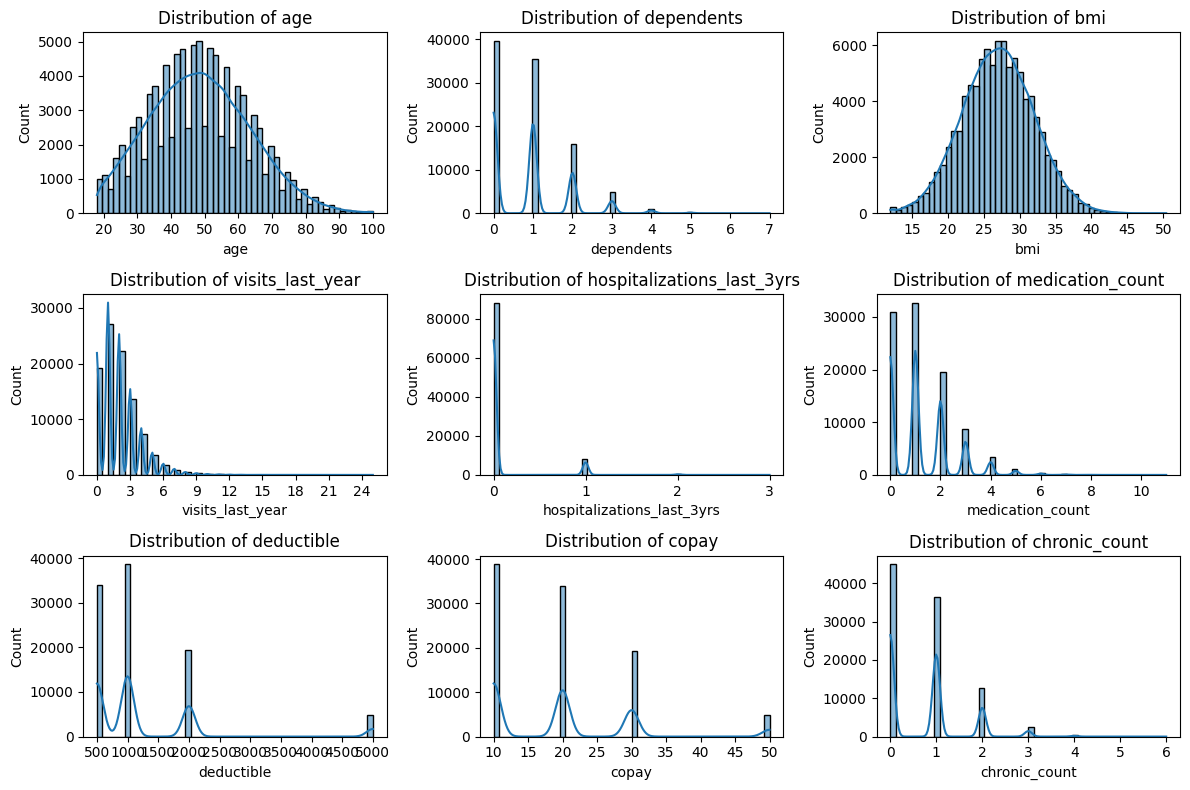

In [7]:
from matplotlib.ticker import MaxNLocator

numerical_cols = ["age", "dependents", "bmi", "visits_last_year", "hospitalizations_last_3yrs", "medication_count", "deductible", "copay", "chronic_count"]

fig, axs = plt.subplots(3, 3, figsize=(12, 8))

for ax, col in zip(axs.ravel(), numerical_cols):
    sns.histplot(data[col], kde=True, ax=ax, linewidth=1, bins=50)
    ax.set_title(f'Distribution of {col}')
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))

fig.tight_layout()

#### Visualization of Categorical features

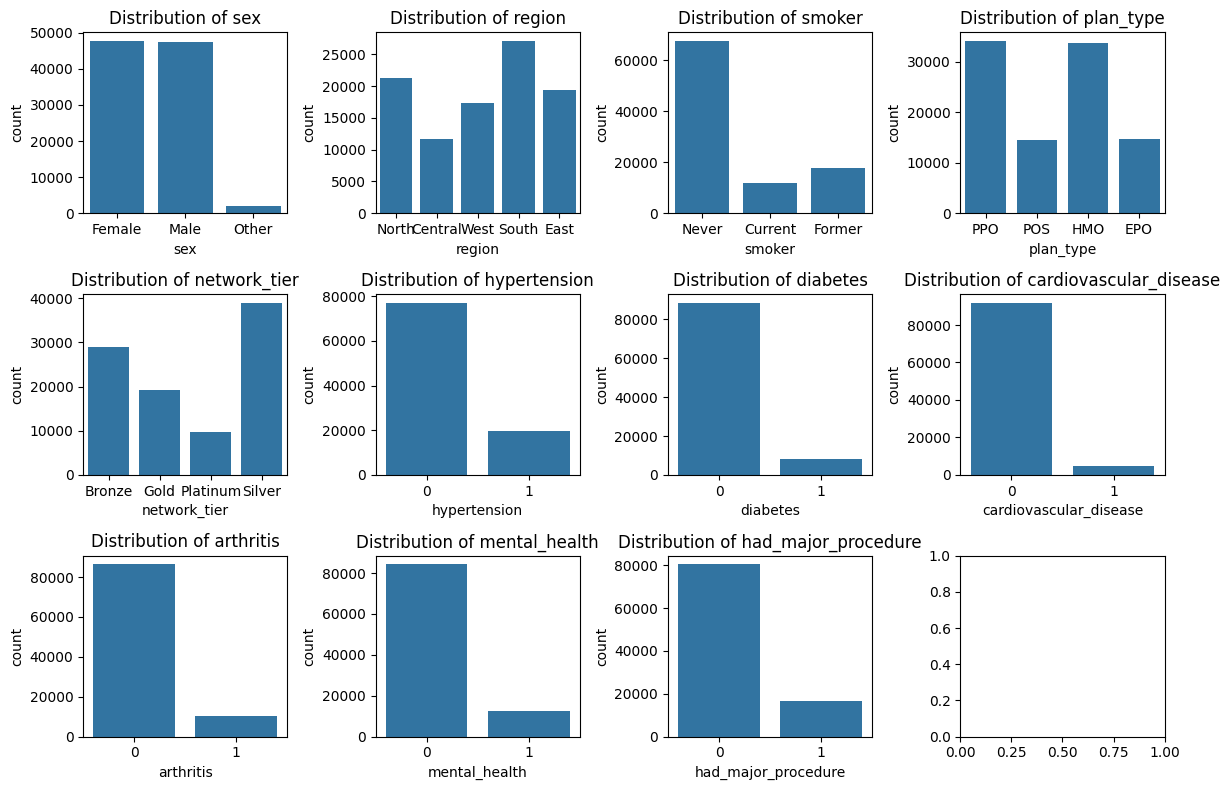

In [8]:
categorical_cols = ["sex", "region", "smoker", "plan_type", "network_tier", "hypertension", "diabetes", "cardiovascular_disease", "arthritis", "mental_health", "had_major_procedure"]

fig, axs = plt.subplots(3, 4, figsize=(12, 8))

for ax, col in zip(axs.ravel(), categorical_cols):
    sns.countplot(x=data[col], ax=ax)
    ax.set_title(f'Distribution of {col}')

fig.tight_layout()

#### Target label distribution

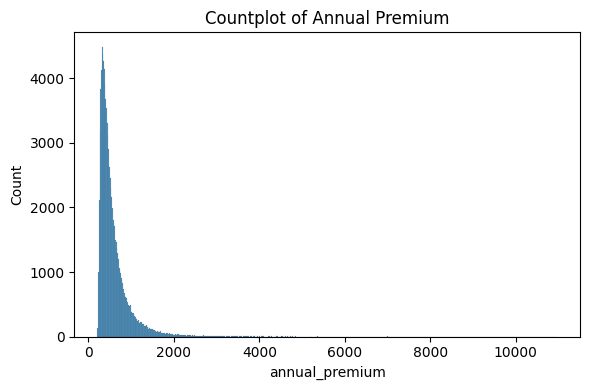

In [9]:
fig = plt.figure(figsize=(6, 4))
sns.histplot(data=data, x='annual_premium')
plt.title('Countplot of Annual Premium')
plt.tight_layout()

### Correlations

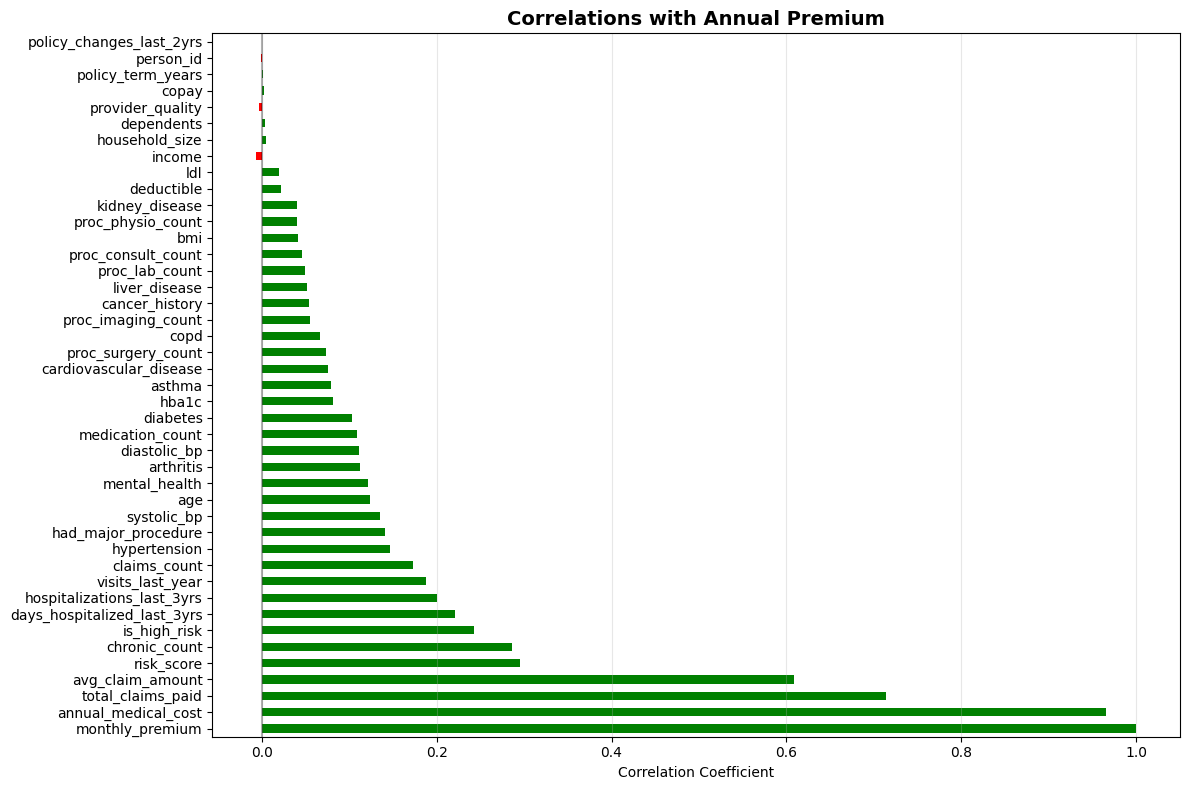

In [10]:
annual_premium_corr = data.corr(numeric_only=True)['annual_premium'].sort_values(key=abs, ascending=False)

plt.figure(figsize=(12, 8))
annual_premium_corr.drop('annual_premium').plot(kind='barh', 
                                                color=['red' if x < 0 else 'green' for x in annual_premium_corr.drop('annual_premium').values])
plt.title('Correlations with Annual Premium', fontsize=14, fontweight='bold')
plt.xlabel('Correlation Coefficient')
plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

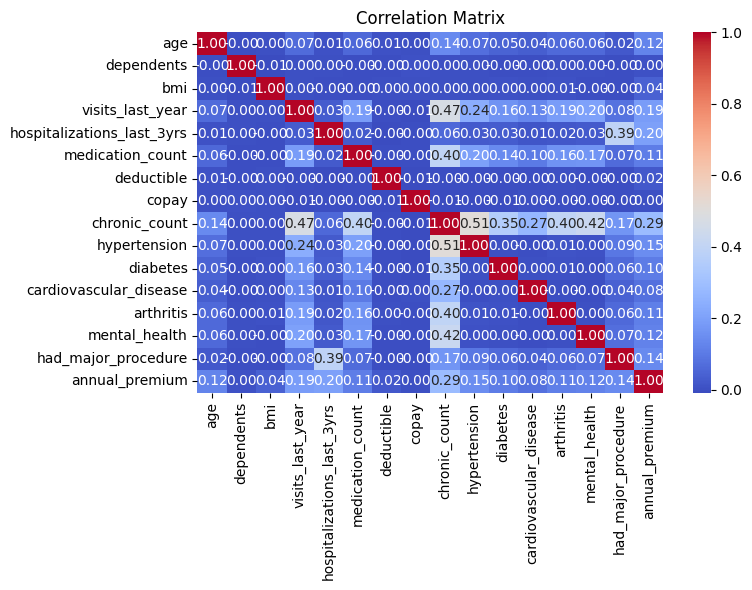

In [11]:
corr_matrix = data[numerical_cols + categorical_cols + ["annual_premium"]].corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()

# ojo con copay, deductible y dependents


<Axes: >

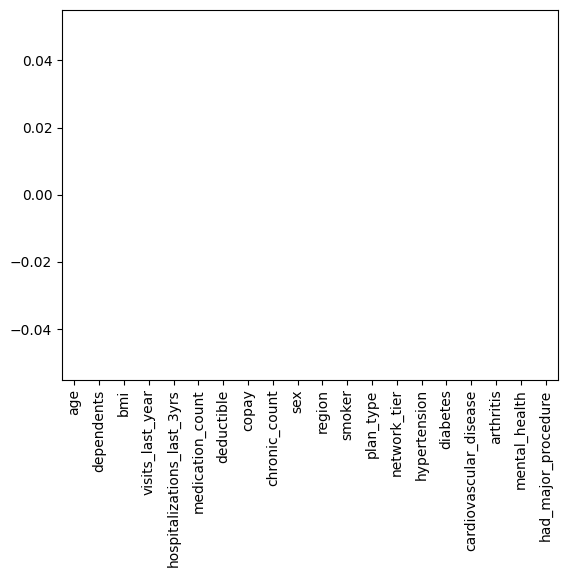

In [12]:
missing_counts = data[numerical_cols + categorical_cols].isnull().sum()
missing_counts.plot(kind='bar')

# There are no missing values in the dataset, so we can proceed with the analysis without needing to handle any NaN values.

## Preprocessing

In [13]:
categorical_cols_OHE = [col for col in categorical_cols if col not in ["smoker", "network_tier"]]

preprocessing_pipeline = make_pipeline(
    ColumnTransformer(
        transformers=[
            ('cat_OHE', make_pipeline(
                SimpleImputer(strategy='most_frequent'), ## para futuro manejo de datos faltantes 
                OneHotEncoder()
            ), categorical_cols_OHE),
            ('cat_Ordinal', make_pipeline(
                SimpleImputer(strategy='most_frequent'),  
                OrdinalEncoder()
            ), ["smoker", "network_tier"]),
            ('skewed_numerical', make_pipeline(
                SimpleImputer(strategy='median'),
                PowerTransformer(),
                StandardScaler()
            ), ["hospitalizations_last_3yrs", "deductible", "visits_last_year", "copay", "medication_count", "dependents", "chronic_count"]),
            ('normal_numerical', make_pipeline(
                SimpleImputer(strategy='mean'), 
                StandardScaler()
            ), ["age", "bmi"]),
        ],
        remainder='passthrough'  
    )
)

In [14]:
x = data[numerical_cols + categorical_cols]
y = data["annual_premium"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

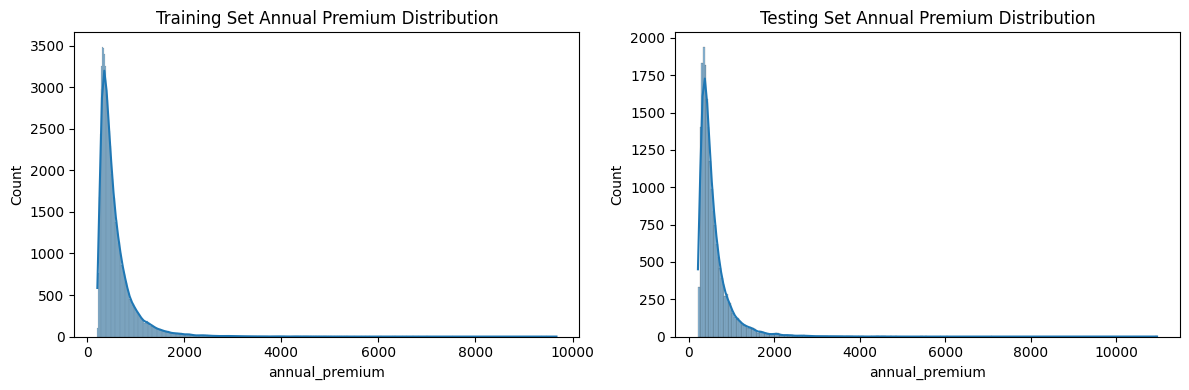

In [15]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(y_train, kde=True, ax=axs[0])
axs[0].set_title('Training Set Annual Premium Distribution')
sns.histplot(y_test, kde=True, ax=axs[1])
axs[1].set_title('Testing Set Annual Premium Distribution')
fig.tight_layout()

In [16]:
x_train_processed = preprocessing_pipeline.fit_transform(x_train, y_train)
x_train_processed

array([[ 1.        ,  0.        ,  0.        , ...,  1.38166862,
         0.2274755 ,  0.22006256],
       [ 0.        ,  1.        ,  0.        , ..., -1.03089971,
         1.17015391,  0.22006256],
       [ 1.        ,  0.        ,  0.        , ...,  0.64922182,
         0.16014133,  0.26009449],
       ...,
       [ 0.        ,  1.        ,  0.        , ...,  0.64922182,
        -1.72521549, -0.8808154 ],
       [ 1.        ,  0.        ,  0.        , ..., -1.03089971,
         1.50682477, -0.86079943],
       [ 0.        ,  1.        ,  0.        , ...,  0.64922182,
        -0.17652953, -0.46048018]], shape=(77564, 35))

In [17]:
x_test_processed = preprocessing_pipeline.transform(x_test)
x_test_processed

array([[ 0.        ,  1.        ,  0.        , ...,  0.64922182,
        -0.64786874, -0.32036844],
       [ 1.        ,  0.        ,  0.        , ...,  0.64922182,
         0.09280716,  1.78130767],
       [ 1.        ,  0.        ,  0.        , ...,  0.64922182,
         1.17015391,  0.18003064],
       ...,
       [ 1.        ,  0.        ,  0.        , ...,  1.38166862,
         0.29480967, -1.56135814],
       [ 1.        ,  0.        ,  0.        , ..., -1.03089971,
        -0.51320039, -0.94086329],
       [ 1.        ,  0.        ,  0.        , ...,  0.64922182,
         0.69881471,  1.78130767]], shape=(19392, 35))

In [18]:
import numpy as np

np.isnan(x_train_processed).sum()              # total NaNs
np.isnan(x_train_processed).sum(axis=0)    

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

# Modeling

Usaremos 3 modelos de regresion y usaremos GridSearchCV en cada uno 

In [ ]:
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Usamos cross validation con 5 folds porque es lo mas generico, no usar 3 
cv = KFold(n_splits=5, shuffle=True, random_state=42)  # el seed para todas las celdas sera 42

Funcion para evaluar modelos todos, 

In [ ]:
import numpy as np
from sklearn.model_selection import cross_validate

# Definimos los scores
scoring = {
    "MAE": "neg_mean_absolute_error",
    "MSE": "neg_mean_squared_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2"
}

# Funcino para volver a correr el modelo para dar metricas generales a parte de la objetivo
# REGULARMENTE SE USA CON EL MEJOR ESTIMADOR DEL ENTRENAMIENTO CV

def cv_metrics(model, X, y, cv):
    res = cross_validate(
        model, X, y,
        scoring=scoring,
        cv=cv,
        n_jobs=-1,
        return_train_score=False
    )
    out = {
        "MAE": -res["test_MAE"].mean(),
        "MSE": -res["test_MSE"].mean(),
        "RMSE": -res["test_RMSE"].mean(),
        "R2": res["test_R2"].mean(),
        "stds para ver cuanto cambian entre folds"
        "\nMAE_std": res["test_MAE"].std(),
        "RMSE_std": res["test_RMSE"].std(),
        "R2_std": res["test_R2"].std(),
    }
    return out

Ridge

In [30]:
from sklearn.linear_model import Ridge

pipe_ridge = Pipeline([
    ("prep", preprocessing_pipeline),
    ("model", Ridge(random_state=42))
])

param_grid_ridge = {
    "model__alpha": [0.01, 0.1, 1, 10, 100]
}

gs_ridge = GridSearchCV(
    estimator=pipe_ridge,
    param_grid=param_grid_ridge,
    scoring="neg_mean_absolute_error",
    cv=cv,
    n_jobs=-1,
    refit=True
)

gs_ridge.fit(x_train, y_train)

print("Ridge best params:", gs_ridge.best_params_)
print("Ridge best CV MAE:", -gs_ridge.best_score_)

best_ridge = gs_ridge.best_estimator_

metrics_ridge = cv_metrics(best_ridge, x_train, y_train, cv)
print("\nRidge CV metrics (promedio):")
for k, v in metrics_ridge.items():
    print(f"{k}: {v}")

Ridge best params: {'model__alpha': 100}
Ridge best CV MAE: 226.84825207064532

Ridge CV metrics (promedio):
MAE: 226.84825207064532
MSE: 137480.96013684504
RMSE: 370.72588276306203
R2: 0.1475544145653313
stds para ver cuanto cambian entre folds
MAE_std: 1.5110309947421963
RMSE_std: 6.578752647230657
R2_std: 0.005810541681672209


KNN Regressor

In [31]:
from sklearn.neighbors import KNeighborsRegressor

pipe_knn = Pipeline([
    ("prep", preprocessing_pipeline),
    ("model", KNeighborsRegressor())
])

param_grid_knn = {
    "model__n_neighbors": [3, 5, 7, 11, 15, 21],
    "model__weights": ["uniform", "distance"],
    "model__p": [1, 2],  # 1=Manhattan, 2=Euclidean
}

gs_knn = GridSearchCV(
    estimator=pipe_knn,
    param_grid=param_grid_knn,
    scoring="neg_mean_absolute_error",
    cv=cv,
    n_jobs=-1,
    refit=True
)

gs_knn.fit(x_train, y_train)

print("KNN best params:", gs_knn.best_params_)
print("KNN best CV MAE:", -gs_knn.best_score_)

best_knn = gs_knn.best_estimator_

metrics_knn = cv_metrics(best_knn, x_train, y_train, cv)
print("\nKNN CV metrics (promedio):")
for k, v in metrics_knn.items():
    print(f"{k}: {v}")

KNN best params: {'model__n_neighbors': 21, 'model__p': 1, 'model__weights': 'uniform'}
KNN best CV MAE: 222.6872059232599

KNN CV metrics (promedio):
MAE: 222.6872059232599
MSE: 141519.20464922025
RMSE: 376.1423558166024
R2: 0.1224161087603814
stds para ver cuanto cambian entre folds
MAE_std: 1.8827717947443594
RMSE_std: 6.0110573077253635
R2_std: 0.0052512168825172385


Huber Regressor

In [33]:
from sklearn.linear_model import HuberRegressor

pipe_huber = Pipeline([
    ("prep", preprocessing_pipeline),
    ("model", HuberRegressor(max_iter=2000))
])

param_grid_huber = {
    "model__epsilon": [1.35, 1.5, 1.75],  # robustez
    "model__alpha": [0.0, 0.001, 0.01],   # regularizacion
}

gs_huber = GridSearchCV(
    estimator=pipe_huber,
    param_grid=param_grid_huber,
    scoring="neg_mean_absolute_error",
    cv=cv,
    n_jobs=-1,
    refit=True
)

gs_huber.fit(x_train, y_train)

print("Huber best params:", gs_huber.best_params_)
print("Huber best CV MAE:", -gs_huber.best_score_)

best_huber = gs_huber.best_estimator_

metrics_huber = cv_metrics(best_huber, x_train, y_train, cv)
print("\nHUBER REGRESOR CV metrics (promedio):")
for k, v in metrics_huber.items():
    print(f"{k}: {v}")

Huber best params: {'model__alpha': 0.01, 'model__epsilon': 1.35}
Huber best CV MAE: 211.63833166326498

HUBER REGRESOR CV metrics (promedio):
MAE: 211.63833166326498
MSE: 146589.3085677116
RMSE: 382.8120051425452
R2: 0.09107313934586236
stds para ver cuanto cambian entre folds
MAE_std: 1.8745540761857982
RMSE_std: 6.6541180073349455
R2_std: 0.00249885104119826


# Metricas


Vamos a priorizar el MAE, porque nos da el error en el valor de los dolares del target entonces es interpretable, y tambien nuestro modelo actualmente tiene muchos outliers por lo que elegimos esta metrica robusta a outliers

NOTA: Para nuestras metricas vamos a priorizar mas tratar de no dar valores por debajo del valor real, porque en nuestro contexto de problema de negocio, no nos conviene decirle a nuestro cliente que su aseguranza le va a salir en 5000 pesos y que llegue y en realidad sean 10 mil pesos, lo mejor es predecir mas arriba cuando se pueda pero no mas abajo del valor real, obviamente manteniendo las predicciones con precision dentro de lo que cabe

**Probar el mejor modelo en test set**

In [ ]:
# best_huber ya esta guardado por el .best_estimator_ , porque puse (refit=True)
y_pred_test = best_huber.predict(x_test)

mae_test = mean_absolute_error(y_test, y_pred_test)

print("Huber TEST MAE:", mae_test)

Huber TEST MAE: 210.8554675025212


**Probaremos los modelos con sus mejores estimadores no importa que no sea el huber**

In [ ]:
# best_knn ya esta guardado por el .best_estimator_ , porque puse (refit=True)
y_pred_test = best_knn.predict(x_test)

mae_test = mean_absolute_error(y_test, y_pred_test)

print("KNN TEST MAE:", mae_test)

KNN TEST MAE: 222.1028925772041


In [ ]:
# best_ridge ya esta guardado por el .best_estimator_ , porque puse (refit=True)
y_pred_test = best_ridge.predict(x_test)

mae_test = mean_absolute_error(y_test, y_pred_test)

print("Ridge TEST MAE:", mae_test)

Ridge TEST MAE: 226.49449935386906


**Huber es el mejor, entonces haremos un reporte de desempeno solo para huber final**

HUBER - Metricas de entrenamiento 
MAE : 211.5624
MSE : 146540.7739
RMSE: 382.8064
R2  : 0.0914

HUBER - Metricas de test 
MAE : 210.8555
MSE : 146140.0637
RMSE: 382.2827
R2  : 0.0950


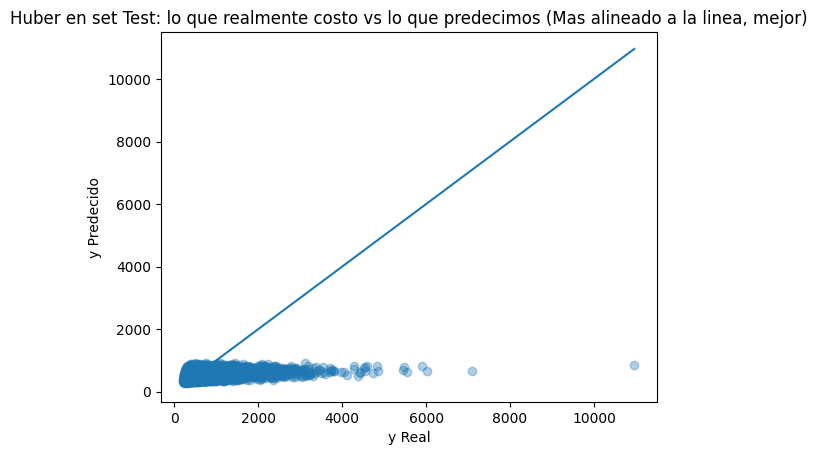

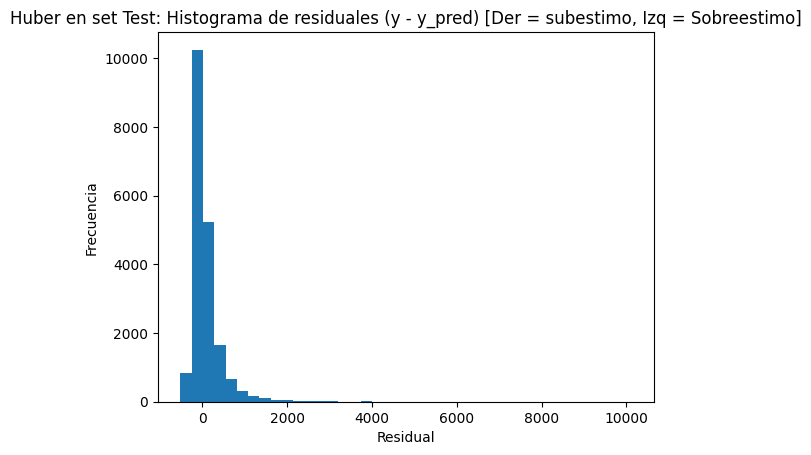

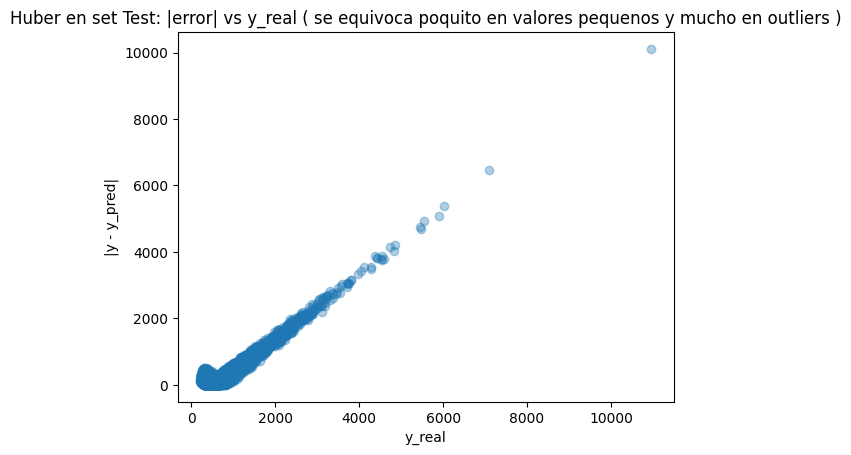

In [47]:
# Celda para evaluar huber, el mejor modelo

# Hacemos una inferencia sobre el set de entrenamiento y test, esto no reentrena el modelo ya que no usamos funcion fit
# Solo es inferencia no reentrenamiento

y_pred_train = best_huber.predict(x_train)
y_pred_test  = best_huber.predict(x_test)

# Definimos las metricas, mae, mse, rmse y r2 como las que hemos estado usando
def reg_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return mae, mse, rmse, r2

# Asignamos los valores de las metricas a variables
train_mae, train_mse, train_rmse, train_r2 = reg_metrics(y_train, y_pred_train)
test_mae,  test_mse,  test_rmse,  test_r2  = reg_metrics(y_test,  y_pred_test)

# Printeamos el reporte 
print("HUBER - Metricas de entrenamiento ")
print(f"MAE : {train_mae:.4f}")
print(f"MSE : {train_mse:.4f}")
print(f"RMSE: {train_rmse:.4f}")
print(f"R2  : {train_r2:.4f}")

print("\nHUBER - Metricas de test ")
print(f"MAE : {test_mae:.4f}")
print(f"MSE : {test_mse:.4f}")
print(f"RMSE: {test_rmse:.4f}")
print(f"R2  : {test_r2:.4f}")

# Este es el bloque para hacer las visualizaciones pertinentes 

# y_real vs y_pred
plt.figure()
plt.scatter(y_test, y_pred_test, alpha=0.35)
minv = min(np.min(y_test), np.min(y_pred_test))
maxv = max(np.max(y_test), np.max(y_pred_test))
plt.plot([minv, maxv], [minv, maxv])
plt.title("Huber en set Test: lo que realmente costo vs lo que predecimos (Mas alineado a la linea, mejor)")
plt.xlabel("y Real")
plt.ylabel("y Predecido")
plt.show()

# Histograma de residuales
res_test = y_test - y_pred_test
plt.figure()
plt.hist(res_test, bins=40)
plt.title("Huber en set Test: Histograma de residuales (y - y_pred) [Der = subestimo, Izq = Sobreestimo]")
plt.xlabel("Residual")
plt.ylabel("Frecuencia")
plt.show()

# error vs y_real
abs_err_test = np.abs(res_test)
plt.figure()
plt.scatter(y_test, abs_err_test, alpha=0.35)
plt.title("Huber en set Test: |error| vs y_real ( se equivoca poquito en valores pequenos y mucho en outliers )")
plt.xlabel("y_real")
plt.ylabel("|y - y_pred|")
plt.show()